In [1]:
# Wildfire Actuarial Risk Score

In [2]:
import math
import re
import warnings
from concurrent.futures import ThreadPoolExecutor

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load all 3 trained models saved by Notebook 04
rf  = joblib.load('../models/random_forest.pkl')
xgb = joblib.load('../models/xgboost.pkl')
gb  = joblib.load('../models/gradient_boosting.pkl')
le  = joblib.load('../models/label_encoder.pkl')

X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

# XGBoost was trained on cleaned column names (no [ ] < characters)
# Apply same cleaning so all models receive identical feature names
import re
clean_cols = [re.sub(r'[\[\]<]', '', col) for col in X_train.columns]
X_train.columns = clean_cols
X_test.columns  = clean_cols

models = {
    'random_forest'    : rf,
    'xgboost'          : xgb,
    'gradient_boosting': gb,
}

print(f"All 3 models loaded: {list(models.keys())}")
print(f"Class order (alphabetical): {list(le.classes_)}")
print(f"X_test  shape : {X_test.shape}")
print(f"X_train shape : {X_train.shape}")
print(f"\nTrue label distribution:")
print(y_test.value_counts())


All 3 models loaded: ['random_forest', 'xgboost', 'gradient_boosting']
Class order (alphabetical): ['High', 'Low', 'Medium']
X_test  shape : (43558, 130)
X_train shape : (318819, 130)

True label distribution:
risk_level
High      26568
Low       16342
Medium      648
Name: count, dtype: int64


In [19]:
# Actuarial weights — manual, reflecting severity ordering of risk classes
weight_vector = np.array([
    1.00 if c == 'High'   else
    0.40 if c == 'Medium' else
    0.10                            # Low
    for c in le.classes_            # aligned to alphabetical class order
])

CLASS_WEIGHTS = dict(zip(le.classes_, weight_vector))

print("Class → Weight mapping:")
for cls, w in CLASS_WEIGHTS.items():
    print(f"  {cls:10s} → {w:.4f}")

formula_parts = ' + '.join(f"P({cls})×{w:.2f}" for cls, w in zip(le.classes_, weight_vector))
print(f"\nFormula: score (0-1) = {formula_parts}")
print(         "         score (0-10) = score (0-1) × 10")

Class → Weight mapping:
  High       → 1.0000
  Low        → 0.1000
  Medium     → 0.4000

Formula: score (0-1) = P(High)×1.00 + P(Low)×0.10 + P(Medium)×0.40
         score (0-10) = score (0-1) × 10


In [20]:
# Risk Score Function
def compute_fire_risk_score(proba_row, thresholds: dict | None = None):
    """
    Converts predict_proba() output into a risk score using the
    data-driven weight_vector.

    Input  : proba_row  — array of 3 probabilities aligned to le.classes_
             thresholds — dict with keys 'low_t', 'high_t' (percentile-based).
                          Falls back to fixed 0.30 / 0.60 if not provided.
    Output : score_01   — normalized score between 0 and 1
             score_010  — risk score between 0 and 10
             label      — risk label (Low / Medium / High)
    """
    score_01  = float(np.dot(proba_row, weight_vector))
    score_010 = round(score_01 * 10, 2)

    low_t  = thresholds['low_t']  if thresholds else 0.30
    high_t = thresholds['high_t'] if thresholds else 0.60

    if score_01 >= high_t:
        label = 'High'
    elif score_01 >= low_t:
        label = 'Medium'
    else:
        label = 'Low'

    return score_01, score_010, label


#  Sanity check 
test_proba = np.array([0.90, 0.02, 0.08])   # [High, Low, Medium] — 90% High
s01, s10, lbl = compute_fire_risk_score(test_proba)

print("Sanity check — property with 90% High probability:")
print(f"  Probabilities : {dict(zip(le.classes_, test_proba))}")
print(f"  Score (0-1)   : {s01:.4f}")
print(f"  Score (0-10)  : {s10}")
print(f"  Risk Label    : {lbl}")


Sanity check — property with 90% High probability:
  Probabilities : {'High': np.float64(0.9), 'Low': np.float64(0.02), 'Medium': np.float64(0.08)}
  Score (0-1)   : 0.9340
  Score (0-10)  : 9.34
  Risk Label    : High


In [33]:
#  Ensemble batch scoring 

def score_batch(model, X_data: pd.DataFrame) -> np.ndarray:
    """Weighted dot product score for every row in X_data."""

    # Get exact columns expected by this model
    if hasattr(model, "feature_names_in_"):
        cols = model.feature_names_in_

    elif hasattr(model, "get_booster"):
        cols = model.get_booster().feature_names

    else:
        cols = X_data.columns

    # Align input to model-specific columns
    X_aligned = X_data.reindex(columns=cols, fill_value=0)

    # Predict probabilities
    proba = model.predict_proba(X_aligned)

    return proba @ weight_vector


print("Scoring all test properties across ensemble …")

with ThreadPoolExecutor(max_workers=3) as ex:
    score_arrays = list(
        ex.map(
            lambda kv: score_batch(kv[1], X_test),
            models.items()
        )
    )

score_matrix = np.stack(score_arrays, axis=1)

fire_scores_01 = score_matrix.mean(axis=1)
score_std = score_matrix.std(axis=1)

fire_scores_010 = (fire_scores_01 * 10).round(2)


#  Percentile thresholds 

THRESHOLDS = {
    'low_t' : 0.30,   # below 3.0/10 = Low
    'high_t': 0.80,   # above 8.0/10 = High
}
low_t  = THRESHOLDS['low_t']
high_t = THRESHOLDS['high_t']
print(f"Thresholds — Low: below {low_t*10}/10  Medium: {low_t*10}–{high_t*10}/10  High: above {high_t*10}/10")


#  Risk labels 

def score_to_label(s):
    if s >= high_t:
        return 'High'
    if s >= low_t:
        return 'Medium'
    return 'Low'


score_labels = [score_to_label(s) for s in fire_scores_01]


# ── Results DataFrame 

results_df = X_test.copy()

results_df['true_risk_level'] = y_test.values
results_df['fire_score_01'] = fire_scores_01.round(4)
results_df['fire_score_010'] = fire_scores_010
results_df['score_std'] = score_std.round(4)
results_df['fire_score_label'] = score_labels


#  Per-model scores 

for i, (name, _) in enumerate(models.items()):
    results_df[f'score_{name}'] = (score_arrays[i] * 10).round(2)


#  RF probabilities 

rf_cols = rf.feature_names_in_
X_rf = X_test.reindex(columns=rf_cols, fill_value=0)

proba_rf = rf.predict_proba(X_rf)

for i, cls in enumerate(le.classes_):
    results_df[f'prob_{cls.lower()}'] = proba_rf[:, i].round(4)


#  Summary 

print(f"\nScored {len(results_df):,} properties")

print("\nScore statistics (0-10 scale):")
print(results_df['fire_score_010'].describe().round(3))

print("\nScore label distribution:")
print(pd.Series(score_labels).value_counts())

print(f"\nMean model disagreement (std): {score_std.mean():.4f}")

Scoring all test properties across ensemble …
Thresholds — Low: below 3.0/10  Medium: 3.0–8.0/10  High: above 8.0/10

Scored 43,558 properties

Score statistics (0-10 scale):
count    43558.000
mean         6.397
std          3.707
min          1.040
25%          1.860
50%          8.720
75%          9.760
max          9.980
Name: fire_score_010, dtype: float64

Score label distribution:
High      23599
Low       14426
Medium     5533
Name: count, dtype: int64

Mean model disagreement (std): 0.0377


In [34]:
# ── Confidence scoring 
# modelConfidence ∈ [0, 1] using:
# confidence = 1 − exp(−n / s)

import math

def build_county_history(train_X: pd.DataFrame) -> pd.Series:
    """
    Count training records per county
    using county_* one-hot columns.
    """

    county_cols = [
        c for c in train_X.columns
        if c.startswith('county_')
    ]

    # Convert one-hot back to county names
    county_series = (
        train_X[county_cols]
        .idxmax(axis=1)
        .str.replace('county_', '', regex=False)
    )

    return county_series.value_counts().rename(
        'historicalRecordCount'
    )


county_history = build_county_history(X_train)

reference_count = max(
    20,
    int(county_history.quantile(0.75))
)

print(
    f"Reference count (75th pct): "
    f"{reference_count:,} training records"
)


def compute_model_confidence(
    n: int,
    scale: int = reference_count
) -> float:
    """
    Saturating confidence:
    1 − exp(−n / scale)

    Returns value in [0, 1]
    """

    return float(
        1.0 - math.exp(
            -max(n, 0) / max(scale, 1)
        )
    )


# ── Map test counties to training history 

county_cols = [
    c for c in X_test.columns
    if c.startswith('county_')
]

test_counties = (
    X_test[county_cols]
    .idxmax(axis=1)
    .str.replace('county_', '', regex=False)
)

record_counts = (
    test_counties
    .map(county_history)
    .fillna(0)
    .astype(int)
)


# ── Add confidence metrics to results 

results_df['historicalRecordCount'] = record_counts.values

results_df['modelConfidence'] = (
    record_counts
    .apply(compute_model_confidence)
    .values
)


# ── Summary 

print("\nConfidence statistics:")
print(results_df['modelConfidence'].describe().round(3))

print("\nSample (first 5 rows):")

print(
    results_df[
        [
            'fire_score_010',
            'score_std',
            'modelConfidence',
            'historicalRecordCount'
        ]
    ].head()
)

Reference count (75th pct): 4,736 training records

Confidence statistics:
count    43558.000
mean         0.896
std          0.204
min          0.000
25%          0.832
50%          1.000
75%          1.000
max          1.000
Name: modelConfidence, dtype: float64

Sample (first 5 rows):
   fire_score_010  score_std  modelConfidence  historicalRecordCount
0            9.87     0.0123         0.963927                  15734
1            5.67     0.0487         0.976147                  17693
2            7.48     0.1719         1.000000                  70096
3            9.86     0.0070         1.000000                 112956
4            1.73     0.0435         0.284275                   1584


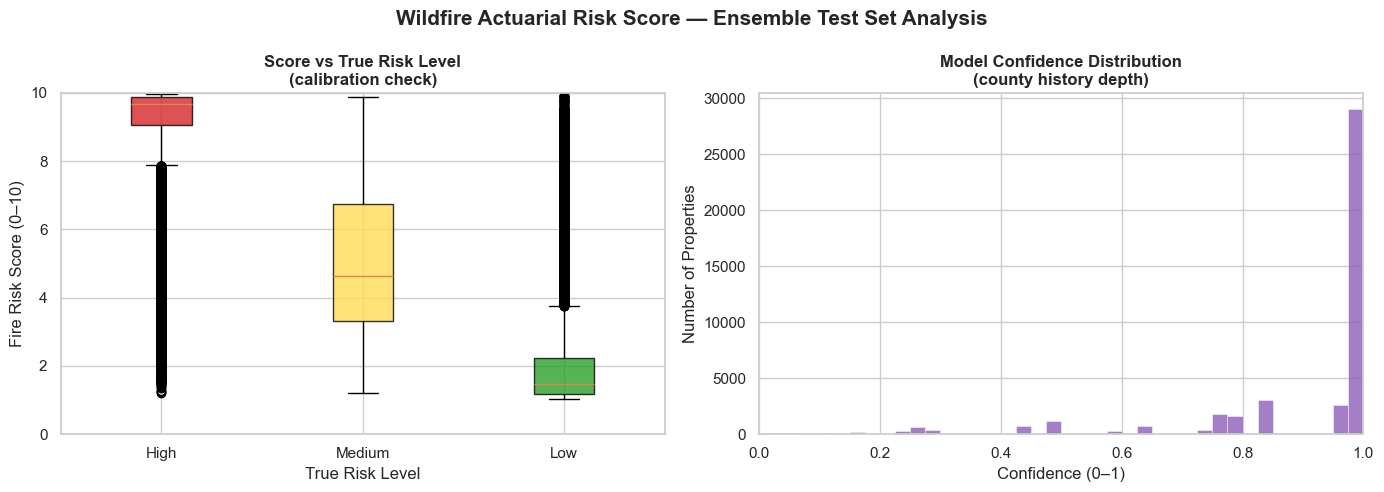

Saved → outputs/11_fire_risk_score_distribution.png


In [35]:
RISK_COLORS = {
    'Low'    : '#2ca02c',
    'Medium' : '#ffdd57',
    'High'   : '#d62728',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
risk_order = ['High', 'Medium', 'Low']

#  Chart 1: Box plot — score vs true risk level 
ax = axes[0]
data_by_risk = [
    results_df.loc[results_df['true_risk_level'] == r, 'fire_score_010'].values
    for r in risk_order
]
bp = ax.boxplot(data_by_risk, labels=risk_order, patch_artist=True)
for patch, r in zip(bp['boxes'], risk_order):
    patch.set_facecolor(RISK_COLORS[r])
    patch.set_alpha(0.8)
ax.set_title('Score vs True Risk Level\n(calibration check)', fontweight='bold')
ax.set_xlabel('True Risk Level')
ax.set_ylabel('Fire Risk Score (0–10)')
ax.set_ylim(0, 10)

#  Chart 2: Model confidence distribution 
ax = axes[1]
ax.hist(results_df['modelConfidence'], bins=40, color='#9467bd', alpha=0.85,
        edgecolor='white', linewidth=0.4)
ax.set_title('Model Confidence Distribution\n(county history depth)', fontweight='bold')
ax.set_xlabel('Confidence (0–1)')
ax.set_ylabel('Number of Properties')
ax.set_xlim(0, 1)

plt.suptitle('Wildfire Actuarial Risk Score — Ensemble Test Set Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
import os
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/11_fire_risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/11_fire_risk_score_distribution.png")

In [36]:
# Single Property Scoring Function

In [37]:
# ── Single property scoring ───────────────────────────────────────────────────
FEATURE_COLS = pd.read_csv('../data/processed/X_train.csv', nrows=0).columns.tolist()
# Apply same column name cleaning used during model training (XGBoost requirement)
import re
FEATURE_COLS = [re.sub(r'[\[\]<]', '', col) for col in FEATURE_COLS]
print(f"Feature vector size: {len(FEATURE_COLS)} columns")


def score_property_fire_risk(property_dict: dict):

    import numpy as np
    import pandas as pd

    input_df = pd.DataFrame([property_dict])

    scores = []
    probas = {}
    per_model_scores = {}

    # ── IMPORTANT: per-model alignment ───────────────────────────────
    for name, mdl in models.items():

        # get model-specific features
        if hasattr(mdl, "feature_names_in_"):
            cols = mdl.feature_names_in_

        elif hasattr(mdl, "get_booster"):
            cols = mdl.get_booster().feature_names

        else:
            cols = input_df.columns

        # ALIGN HERE (this is what fixes your crash)
        aligned = input_df.reindex(columns=cols, fill_value=0)

        # SAFE PREDICTION (NOT raw input_df)
        proba = mdl.predict_proba(aligned)[0]

        score = float(np.dot(proba, weight_vector))
        scores.append(score)

        per_model_scores[name] = round(score * 10, 2)

        probas[name] = {
            cls: round(float(p), 4)
            for cls, p in zip(le.classes_, proba)
        }

    # ── ensemble ─────────────────────────────────────────────────────
    score_01 = float(np.mean(scores))
    score_010 = round(score_01 * 10, 2)
    score_std = float(np.std(scores))

    # ── label ────────────────────────────────────────────────────────
    if score_01 >= high_t:
        risk_label = "High"
    elif score_01 >= low_t:
        risk_label = "Medium"
    else:
        risk_label = "Low"

    # ── county confidence ───────────────────────────────────────────
    county_cols = [c for c in input_df.columns if c.startswith("county_")]

    if county_cols:
        county = (
            input_df[county_cols]
            .idxmax(axis=1)
            .iloc[0]
            .replace("county_", "")
        )
        n = int(county_history.get(county, 0))
    else:
        n = 0

    model_conf = compute_model_confidence(n)

    return {
        "fire_score_01": round(score_01, 4),
        "fire_score_010": score_010,
        "risk_label": risk_label,
        "score_std": round(score_std, 4),

        "modelConfidence": round(model_conf, 4),
        "historicalRecords": n,

        "per_model_scores": per_model_scores,
        "class_probabilities": probas
    }

Feature vector size: 130 columns


In [38]:
# Example: Score a Single Property

result = score_property_fire_risk({
    # ── Fire event features
    'gis_acres': 153335.6,
    'fire_duration_days': 18.0,
    'fire_year': 2024,
    'cause': 11.0,
    'area_burned': 33326.0,
    'homes_destroyed': 1017.0,
    'financial_loss_million': 3381.87,
    'fatalities': 17.0,

    # ── Property features 

    'assessed_value': 17547.0,
    'year_built': 1946.0,
    'latitude': 39.783418,
    'longitude': -121.587059,

     # ── County (one-hot)

    'county_BUTTE': 1,

     # ── Construction features (one-hot) 

    'roof_construction_Asphalt': 1,
    'eaves_Unenclosed': 1,
    'exterior_siding_Combustible': 1,
    'window_pane_Single Pane': 1,
    'structure_category_Other Minor Structure': 1,
    'structure_type_Utility Misc Structure': 1,

    'vent_screen_Mesh Screen = 1/8""': 1,
})

print("=" * 44)
print("    WILDFIRE RISK SCORE REPORT")
print("=" * 44)
print(f"  Score (0-1)        :  {result['fire_score_01']}")
print(f"  Score (0-10)       :  {result['fire_score_010']}  ← FINAL RISK SCORE")
print(f"  Risk Label         :  {result['risk_label']}")
print(f"  Model Std Dev      :  {result['score_std']}  ← model agreement (lower = more reliable)")
print(f"  Model Confidence   :  {result['modelConfidence']}  ← county data depth (0-1)")
print(f"  Historical Records :  {result['historicalRecords']} training claims for this county")
print("=" * 44)
print(f"\nPer-Model Scores (0-10):")
for name, s in result['per_model_scores'].items():
    print(f"  {name:22s} : {s}")
print(f"\nClass Probabilities (from each model):")
for model_name, probs in result['class_probabilities'].items():
    print(f"  {model_name}:")

    for cls, prob in probs.items():
        print(f"    {cls:10s} : {prob:.4f}")


    WILDFIRE RISK SCORE REPORT
  Score (0-1)        :  0.8715
  Score (0-10)       :  8.71  ← FINAL RISK SCORE
  Risk Label         :  High
  Model Std Dev      :  0.0705  ← model agreement (lower = more reliable)
  Model Confidence   :  1.0  ← county data depth (0-1)
  Historical Records :  112956 training claims for this county

Per-Model Scores (0-10):
  random_forest          : 7.84
  xgboost                : 9.57
  gradient_boosting      : 8.74

Class Probabilities (from each model):
  random_forest:
    High       : 0.7100
    Low        : 0.1400
    Medium     : 0.1500
  xgboost:
    High       : 0.9494
    Low        : 0.0433
    Medium     : 0.0072
  gradient_boosting:
    High       : 0.8474
    Low        : 0.1157
    Medium     : 0.0369


In [40]:
result = score_property_fire_risk({
    'gis_acres'                : 85.0,
    'fire_duration_days'       : 1.0,
    'fire_year'                : 2021,
    'cause'                    : 1.0,
    'area_burned'              : 20.0,
    'homes_destroyed'          : 0.0,
    'financial_loss_million'   : 2.5,
    'fatalities'               : 0.0,

    'assessed_value'           : 620000.0,
    'year_built'               : 2015.0,
    'latitude'                 : 34.052,
    'longitude'                : -118.243,

    'county_LOS ANGELES'       : 1,

    'roof_construction_Tile'   : 1,
    'eaves_Enclosed'           : 1,
    'exterior_siding_Stucco'   : 1,
    'window_pane_Double Pane'  : 1,
    'structure_category_Single Family Residence' : 1,
    'structure_type_Single Family Dwelling'      : 1,
})
print("=" * 44)
print("    WILDFIRE RISK SCORE REPORT")
print("=" * 44)
print(f"  Score (0-1)        :  {result['fire_score_01']}")
print(f"  Score (0-10)       :  {result['fire_score_010']}  ← FINAL RISK SCORE")
print(f"  Risk Label         :  {result['risk_label']}")
print(f"  Model Std Dev      :  {result['score_std']}  ← model agreement (lower = more reliable)")
print(f"  Model Confidence   :  {result['modelConfidence']}  ← county data depth (0-1)")
print(f"  Historical Records :  {result['historicalRecords']} training claims for this county")
print("=" * 44)
print(f"\nPer-Model Scores (0-10):")
for name, s in result['per_model_scores'].items():
    print(f"  {name:22s} : {s}")
print(f"\nClass Probabilities (from each model):")
for model_name, probs in result['class_probabilities'].items():
    print(f"  {model_name}:")

    for cls, prob in probs.items():
        print(f"    {cls:10s} : {prob:.4f}")


    WILDFIRE RISK SCORE REPORT
  Score (0-1)        :  0.2037
  Score (0-10)       :  2.04  ← FINAL RISK SCORE
  Risk Label         :  Low
  Model Std Dev      :  0.0567  ← model agreement (lower = more reliable)
  Model Confidence   :  1.0  ← county data depth (0-1)
  Historical Records :  70096 training claims for this county

Per-Model Scores (0-10):
  random_forest          : 2.8
  xgboost                : 1.44
  gradient_boosting      : 1.87

Class Probabilities (from each model):
  random_forest:
    High       : 0.1300
    Low        : 0.6600
    Medium     : 0.2100
  xgboost:
    High       : 0.0454
    Low        : 0.9440
    Medium     : 0.0107
  gradient_boosting:
    High       : 0.0686
    Low        : 0.8464
    Medium     : 0.0850


In [45]:
medium_idx = results_df[
    (results_df['fire_score_010'] >= 3.0) &
    (results_df['fire_score_010'] < 8.0)
].index[0]

# Get the original feature values
medium_features = X_test.loc[medium_idx].to_dict()

# Score it
result = score_property_fire_risk(medium_features)

print("=" * 44)
print("    WILDFIRE RISK SCORE REPORT")
print("=" * 44)
print(f"  Score (0-10)       :  {result['fire_score_010']}  ← FINAL RISK SCORE")
print(f"  Risk Label         :  {result['risk_label']}")
print(f"  Model Std Dev      :  {result['score_std']}")
print(f"  Model Confidence   :  {result['modelConfidence']}")
print(f"  Historical Records :  {result['historicalRecords']}")
print("=" * 44)
print(f"\nPer-Model Scores (0-10):")
for name, s in result['per_model_scores'].items():
    print(f"  {name:22s} : {s}")
print(f"\nClass Probabilities (from each model):")
for model_name, probs in result['class_probabilities'].items():
    print(f"  {model_name}:")
    for cls, prob in probs.items():
        print(f"    {cls:10s} : {prob:.4f}")

    WILDFIRE RISK SCORE REPORT
  Score (0-10)       :  5.67  ← FINAL RISK SCORE
  Risk Label         :  Medium
  Model Std Dev      :  0.0487
  Model Confidence   :  0.9761
  Historical Records :  17693

Per-Model Scores (0-10):
  random_forest          : 5.17
  xgboost                : 6.33
  gradient_boosting      : 5.51

Class Probabilities (from each model):
  random_forest:
    High       : 0.4600
    Low        : 0.5300
    Medium     : 0.0100
  xgboost:
    High       : 0.5121
    Low        : 0.2476
    Medium     : 0.2403
  gradient_boosting:
    High       : 0.3444
    Low        : 0.1872
    Medium     : 0.4684
